Created 7/23.

Based on FORCE_tracking_addshift.ipynb

Refer to Antoine's Best_results_equilibrium_feedback_hebbianlearning_Kris.ipynb

Updated 7/24: u_norm change to average L1 norm, input sparse matrix at least value one each row

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import tensor
from torch import nn
import seaborn as sns
from torch.autograd.functional import jacobian
from tqdm.notebook import tqdm
import scipy as sp

In [32]:
SAVEFIG = True
filename = "final"
date = "0724"

In [3]:
# Initializing matrix
num_nodes = 200
np.random.seed(6)

connectivity_matrix = np.ones((num_nodes, num_nodes))
weight_matrix = np.random.normal(0, 1 / np.sqrt(num_nodes), (num_nodes, num_nodes))
for i in range(num_nodes):
    weight_matrix[i, i] = 0
    connectivity_matrix[i, i] = 0
output_weight_matrix = np.random.uniform(-1, 1, (1, num_nodes))
feedback_weight_matrix = np.random.uniform(-1, 1, (num_nodes, 1))  # * 0.5
init_state = np.random.uniform(-0.5, 0.5, (num_nodes, 1))
init_gain = np.ones((num_nodes, 1))
init_shift = np.zeros((num_nodes, 1))

# Dale's Law
excite_perc = 0.5
excite_num = int(excite_perc * num_nodes)
node_type = np.array([1] * excite_num + [-1] * (num_nodes - excite_num))
weight_type = np.tile(node_type, num_nodes).reshape(num_nodes, -1)

# Enforce Dale's Law
weight_matrix = np.abs(weight_matrix) * weight_type
output_weight_matrix = np.abs(output_weight_matrix) * node_type

# normalize
ext_weight_sum = num_nodes / 4
inh_weight_sum = num_nodes / 4
tmp_output_weight_matrix = output_weight_matrix.copy()
tmp_ext = tmp_output_weight_matrix[:, node_type == 1]
tmp_inh = tmp_output_weight_matrix[:, node_type == -1]
tmp_ext /= np.sum(np.abs(tmp_ext)) / ext_weight_sum
tmp_inh /= np.sum(np.abs(tmp_inh)) / inh_weight_sum
tmp_output_weight_matrix[:, node_type == 1] = tmp_ext
tmp_output_weight_matrix[:, node_type == -1] = tmp_inh
output_weight_matrix = tmp_output_weight_matrix.copy()
init_output_weight_matrix = output_weight_matrix.copy()

In [4]:
# define targets
t_max = 30000
time_points = np.arange(t_max)
half_period = 10
targets = (np.sin((time_points + 5) / half_period * np.pi)) / 4 + 0.5

# # inputs with different phases
# np.random.seed(3)
# inputs = []
# for i in range(num_nodes):
#     this_half_period = np.random.randint(8, 13)  # narrowed
#     this_half_period = np.random.choice([8, 10, 12])
#     this_input = (np.sin((time_points + np.random.randint(0, this_half_period*2))/this_half_period*np.pi))/4 + 0.5
#     inputs.append(this_input)
# inputs = np.array(inputs)

# inputs with different phases
np.random.seed(3)
num_basis = 500  # this can be different than num_nodes
input_basis = []
for i in range(num_basis):
    # this_half_period = np.random.randint(8, 13)
    this_half_period = np.random.choice([8, 10, 12])
    this_input = (np.sin((time_points + np.random.randint(0, this_half_period * 2)) / this_half_period * np.pi)) / 4 + 0.5
    input_basis.append(this_input)
input_basis = np.array(input_basis)

# get input to every node by going through a sparse matrix
# put a random value to random position for each row, to eusure no empty row
input_sparse_matrix = np.zeros((num_nodes, num_basis))
for i in range(num_nodes):
    input_sparse_matrix[i, np.random.randint(0, num_basis)] = np.random.rand()
# add extra random connections
extra_avgcomb_num = 2
density = extra_avgcomb_num / num_basis
input_sparse_matrix = input_sparse_matrix + sp.sparse.random(num_nodes, num_basis, density=density).toarray()
input_sparse_matrix = input_sparse_matrix / np.sum(input_sparse_matrix, axis=1)[:, np.newaxis]  # normalize each row of input_sparse_matrix
# input_sparse_matrix = np.concatenate([np.eye(num_nodes), np.zeros((num_nodes, num_basis - num_nodes))], axis=1)
inputs = input_sparse_matrix @ input_basis

Text(0.5, 1.0, 'Inputs')

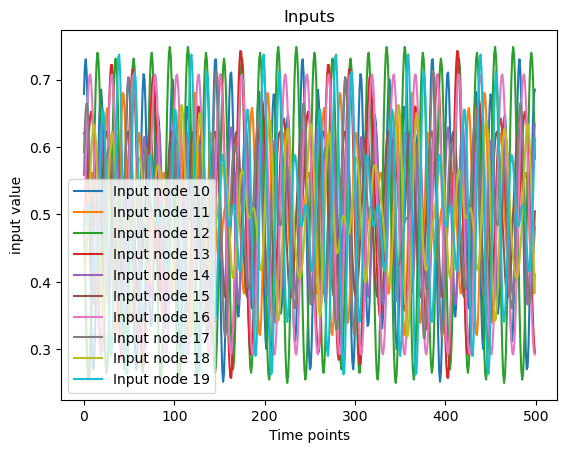

In [5]:
plt.figure()
for i in range(10, 20):
    plt.plot(np.arange(500), inputs[i, :500], label="Input node {}".format(i))
plt.legend()
plt.xlabel("Time points")
plt.ylabel("input value")
plt.title("Inputs")

In [6]:
# define sigmoid
def sigmoid_np(x):
    return 1 / (1 + np.exp(-x))


def inv_sigmoid_np(x):
    return -np.log((1 / x) - 1)

In [7]:
# imitate rnn_FORCE
class mysys:
    def __init__(self, weight_matrix, connectivity_matrix, gain, shift, input_weight_matrix=None, inputs=None):
        # core parameters
        self.weight_matrix = weight_matrix
        self.connectivity_matrix = connectivity_matrix
        self.gain = gain
        self.shift = shift
        self.inputs = inputs
        self.input_weight_matrix = input_weight_matrix
        self.activation_func = nn.Sigmoid()

        # transfer into tensor
        self.weight_matrix_tensor = tensor(self.weight_matrix)
        self.gain_tensor = tensor(self.gain)
        self.shift_tensor = tensor(self.shift)

        # constants
        self.time_const = 1
        self.timestep = 0.1
        self.c = self.timestep / self.time_const
        self.g = 1.5

    def f_tensor(self, x_tensor, ug_tensor, us_tensor, r_tensor):
        # this_input_tensor = torch.matmul(tensor(self.input_weight_matrix), tensor([[self.inputs[self.i]]]))
        y_tensor = (1 - self.c) * x_tensor + self.c * self.activation_func(
            (self.gain_tensor + ug_tensor) * (self.g * torch.matmul(self.weight_matrix_tensor, x_tensor) + r_tensor - (self.shift_tensor + us_tensor))
        )
        return y_tensor

    def f(self, x, ug, us, r):
        x_tensor = tensor(x)
        ug_tensor = tensor(ug)
        us_tensor = tensor(us)
        r_tensor = tensor(r)
        y_tensor = self.f_tensor(x_tensor, ug_tensor, us_tensor, r_tensor)
        y = y_tensor.numpy()
        return y

    def jacob(self, x, ug, us, r):
        x_tensor = tensor(x)
        ug_tensor = tensor(ug)
        us_tensor = tensor(us)
        r_tensor = tensor(r)
        dydx, dydug, dydus, dydr = jacobian(self.f_tensor, (x_tensor, ug_tensor, us_tensor, r_tensor))
        Jx_tensor = dydx.squeeze(dim=(1, 3))
        Jug_tensor = dydug.squeeze(dim=(1, 3))
        Jus_tensor = dydus.squeeze(dim=(1, 3))
        Jr_tensor = dydr.squeeze(dim=(1, 3))
        Jx = Jx_tensor.numpy()
        Jug = Jug_tensor.numpy()
        Jus = Jus_tensor.numpy()
        Jr = Jr_tensor.numpy()
        return Jx, Jug, Jus, Jr


jnn_ff = mysys(weight_matrix, connectivity_matrix, init_gain, init_shift)
jnn = mysys(weight_matrix, connectivity_matrix, init_gain, init_shift)

In [8]:
# calculate the desired output before the output sigmoid
gainout = 1
shiftout = 0
y_tildes = inv_sigmoid_np(targets) / gainout + shiftout

# temporary
y_tildes = (y_tildes - np.mean(y_tildes)) / (np.max(y_tildes) - np.min(y_tildes))
targets = sigmoid_np(y_tildes * gainout + shiftout)

# calculate mean and amplitude for later rescale
# desire_mean = 0  # np.mean(y_tildes) is 0
# desire_amp = np.max(y_tildes) - np.min(y_tildes)
# desire_amp = 1
desire_mean = 0.5
desire_amp = np.max(targets) - np.min(targets)
desire_mean, desire_amp

(0.5, 0.2449186624037092)

In [9]:
# rescale mechanism
def cal_rescale_coef(x, desire_mean, desire_amp):
    x_mean = np.mean(x)
    x_amp = np.max(x) - np.min(x)
    amp_coef = desire_amp / x_amp
    mean_coef = desire_mean - x_mean * amp_coef
    return mean_coef, amp_coef


def cal_mean_amp(x):
    x_mean = np.mean(x)
    x_amp = np.max(x) - np.min(x)
    return x_mean, x_amp


def cal_mean_amp_ref(ref_xs, this_output_weight_matrix):
    xs_np = np.concatenate(ref_xs, axis=1)
    y = this_output_weight_matrix @ xs_np
    y_mean = np.mean(y)
    y_amp = np.max(y) - np.min(y)
    return y_mean, y_amp

### Simulate Without Control

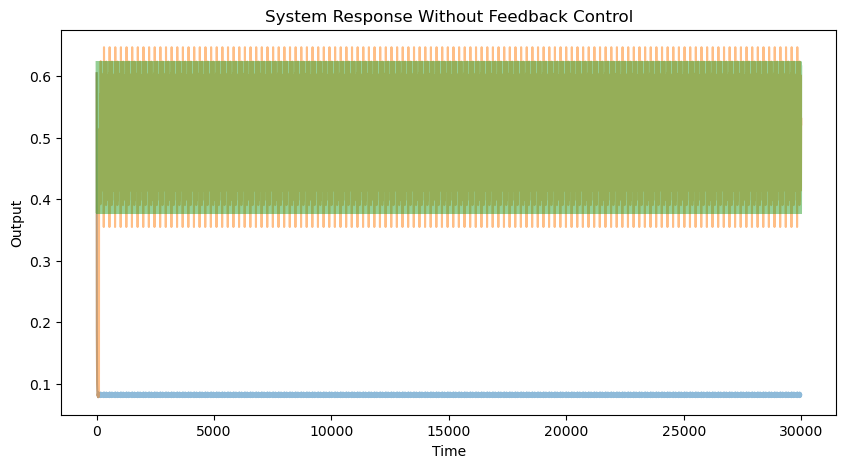

In [10]:
# Simulation Without Control
x = sigmoid_np(init_gain * (init_state.copy() - init_shift))
ug = init_state.copy() * 0
us = init_state.copy() * 0
xs_ff_init, outputs_ff_init, outputs_ff_init_rescale = [x], [], []
lookback_out = 100

for i in time_points[:-1]:

    # output
    output_beforesig = output_weight_matrix @ x
    output = sigmoid_np(gainout * (output_beforesig - shiftout))

    # rescale
    if i > lookback_out:
        ref_period_out = outputs_ff_init[-(lookback_out + 1) : -1]
        mean_coef, amp_coef = cal_rescale_coef(ref_period_out, desire_mean, desire_amp)
        output_rescale = output * amp_coef + mean_coef
    else:
        output_rescale = output

    # input
    this_input = inputs[:, i]
    r = feedback_weight_matrix * this_input.reshape(-1, 1)

    # update x
    x1 = jnn_ff.f(x, ug, us, r)
    x = x1.copy()

    # save
    xs_ff_init.append(x)
    outputs_ff_init.append(output.item())
    outputs_ff_init_rescale.append(output_rescale.item())

# final readout for x_T
output_beforesig = output_weight_matrix @ x
output = sigmoid_np(gainout * (output_beforesig - shiftout))
ref_period_out = outputs_ff_init[-(lookback_out + 1) : -1]
mean_coef, amp_coef = cal_rescale_coef(ref_period_out, desire_mean, desire_amp)
output_rescale = output * amp_coef + mean_coef
outputs_ff_init.append(output.item())
outputs_ff_init_rescale.append(output_rescale.item())

# Plot the output
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(time_points, outputs_ff_init, alpha=0.5)
plt.plot(time_points, outputs_ff_init_rescale, alpha=0.5)
plt.plot(time_points, targets, alpha=0.5)
plt.xlabel("Time")
plt.ylabel("Output")
plt.title("System Response Without Feedback Control")
plt.show()

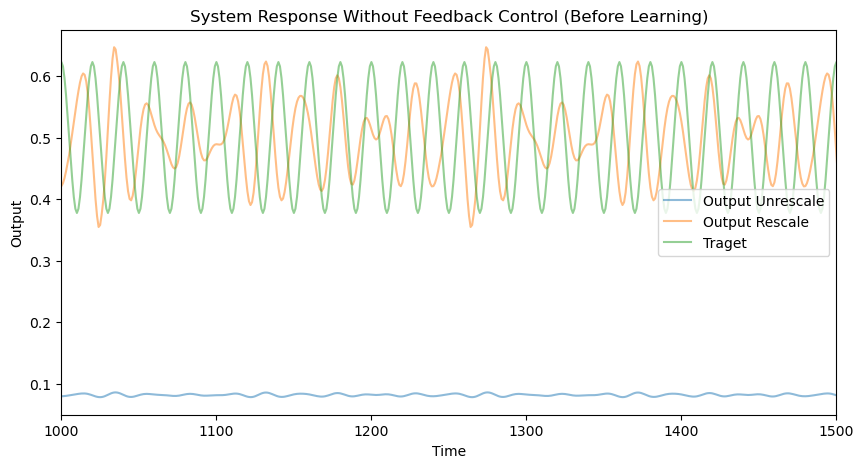

In [33]:
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(time_points, outputs_ff_init, alpha=0.5, label="Output Unrescale")
plt.plot(time_points, outputs_ff_init_rescale, alpha=0.5, label="Output Rescale")
plt.plot(time_points, targets, alpha=0.5, label="Traget")
plt.xlabel("Time")
plt.ylabel("Output")
plt.title("System Response Without Feedback Control (Before Learning)")
plt.xlim(1000, 1500)
plt.legend()
if SAVEFIG:
    plt.savefig(f"fig/{date}_{filename}_ffoutputs.png")

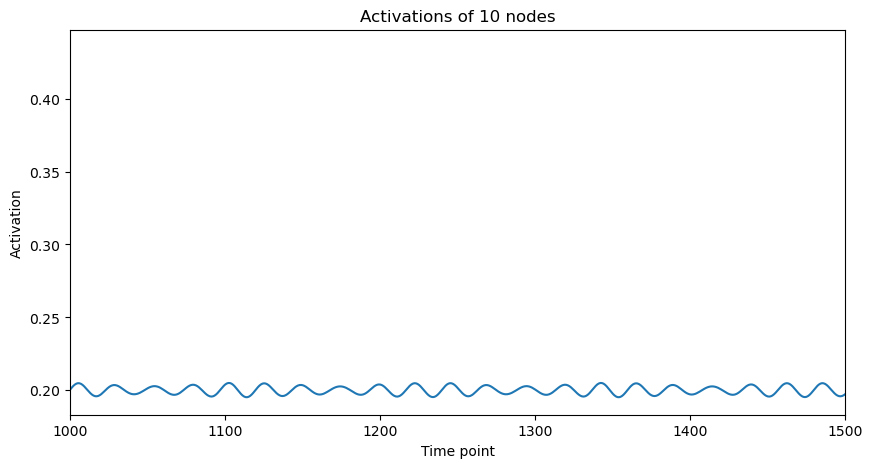

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
all_xs_ff_init = np.concatenate(xs_ff_init, axis=1)
for i in range(83, 84):
    plt.plot(all_xs_ff_init[i, :], label=f"Node {i}")
plt.xlabel("Time point")
plt.ylabel("Activation")
plt.title("Activations of 10 nodes")
plt.xlim(1000, 1500)
if SAVEFIG:
    plt.savefig(f"fig/{date}_{filename}_ffactivations.png")

Definition of phase here: phase = 0 means peak at timepoint 0

Target now has phase = 0

In [13]:
# mean of each node
stable_point = 200
mean_activation = np.mean(all_xs_ff_init[:, stable_point:], axis=1)

In [14]:
periods = []
phases = []
for i in range(num_nodes):
    # for each node, find the time point when it reaches the local maximum
    peak_time = []
    for j in range(stable_point, len(time_points) - 1):
        if all_xs_ff_init[i, j - 1] < all_xs_ff_init[i, j] and all_xs_ff_init[i, j] > all_xs_ff_init[i, j + 1]:
            peak_time.append(j)

    peak_time_diff = np.diff(peak_time)
    this_period = np.mean(peak_time_diff).round()
    this_phase = peak_time[0] % this_period

    periods.append(this_period)
    phases.append(this_phase)

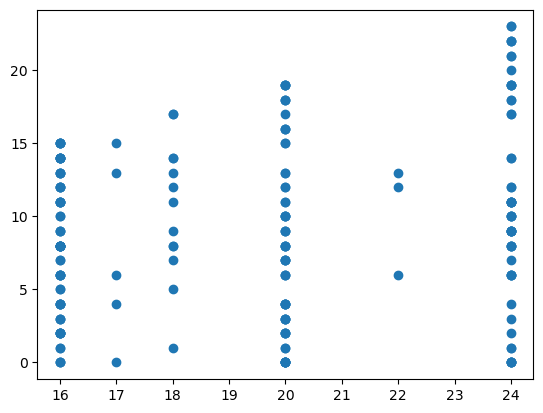

In [15]:
# plot the periods and phases
plt.scatter(periods, phases)

Text(0.5, 1.0, 'Distribution of Phase and Period for Excitatory Nodes')

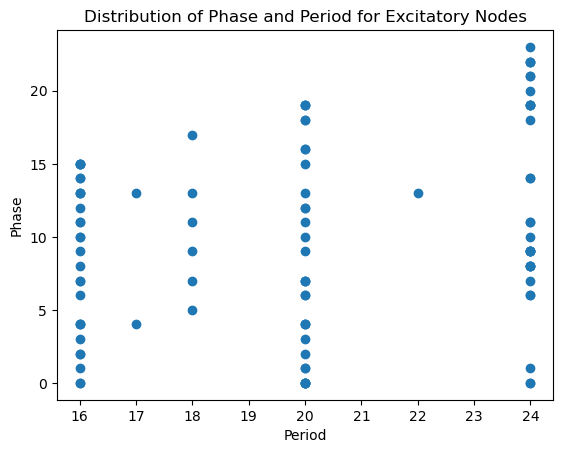

In [16]:
# plot the periods and phases
plt.scatter(np.array(periods)[node_type == 1], np.array(phases)[node_type == 1])
plt.ylabel("Phase")
plt.xlabel("Period")
plt.title("Distribution of Phase and Period for Excitatory Nodes")
# if SAVEFIG:
#     plt.savefig(f"fig/{date}_{filename}_phase_period.png")

Text(0, 0.5, 'Output weight')

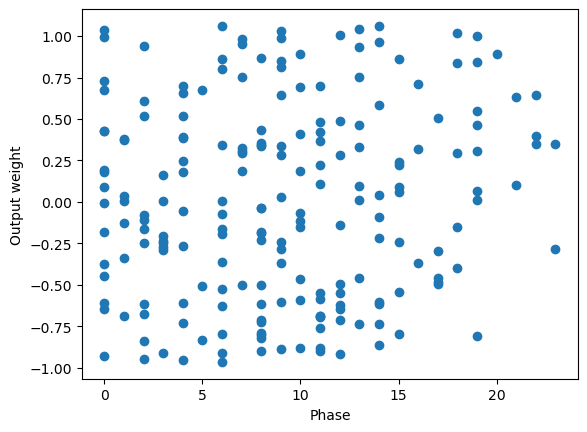

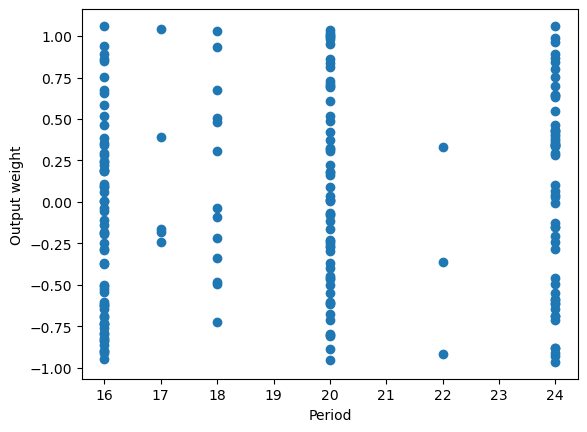

In [17]:
# plot init_output_weight_matrix against phases
plt.subplots()
plt.scatter(phases, init_output_weight_matrix.flatten())
plt.xlabel("Phase")
plt.ylabel("Output weight")

# plot init_output_weight_matrix against periods
plt.subplots()
plt.scatter(periods, init_output_weight_matrix.flatten())
plt.xlabel("Period")
plt.ylabel("Output weight")

### FB Control + Hebbian Learning (Kris's Rule)

In [18]:
# Simulate with control + Hebb + adjout
x = sigmoid_np(init_gain * (init_state.copy() - init_shift))
u_zeros = np.zeros_like(init_state)
ug = u_zeros.copy()
us = u_zeros.copy()
this_output_weight_matrix = output_weight_matrix.copy()
xs_kris, ugs_kris, uss_kris, outputs_kris_beforesig, outputs_kris, outputs_kris_rescale = [x], [], [], [], [], []
output_weights = [this_output_weight_matrix.copy()]
y_means, y_amps = [], []
has_hebbian = False
has_boundary = False

# constants
R = np.eye(2 * num_nodes) * 0.0001
Q1 = np.eye(num_nodes) * 0
Q2 = np.eye(1) * 10
pos_hebbian_lr = 0.05
alpha = 7 / 5
neg_hebbian_lr = pos_hebbian_lr * alpha
beta = 0.25
period = 2 * half_period
# lookback = 1000
lookback_output = 100
t_control = 1100
t_hebb = 2000
# t_decay = 10000

for t in tqdm(time_points[:-1]):

    # output
    output_beforesig = this_output_weight_matrix @ x
    output = sigmoid_np(gainout * (output_beforesig - shiftout))

    # rescale output once start feedback control
    if t > lookback_output:
        ref_period_output = outputs_kris[-(lookback_output + 1) : -1]
        mean_coef, amp_coef = cal_rescale_coef(ref_period_output, desire_mean, desire_amp)
        output_rescale = output * amp_coef + mean_coef
    else:
        output_rescale = output

    # update readout weights by hebbian learning
    if not has_hebbian and t > t_hebb:
        has_hebbian = True
    if has_hebbian:
        # ref period for mean and std
        xs_kris_ref = np.concatenate(xs_kris[-(lookback_output + 1) : -1], axis=1)
        x_mean = xs_kris_ref.mean(axis=1).reshape(-1, 1)
        x_std = xs_kris_ref.std(axis=1).reshape(-1, 1)
        output_mean, output_amp = cal_mean_amp(ref_period_output)
        # Calculate Hebbian weight updates, only for ext nodes
        hebbian_update = (((output - output_mean) / output_amp) * ((x - x_mean) / x_std).T)[:, node_type == 1]
        ext_output_weight_matrix = this_output_weight_matrix[:, node_type == 1]
        f_plus = np.power(1 - ext_output_weight_matrix / ext_weight_sum, beta)
        f_minus = np.power(ext_output_weight_matrix / ext_weight_sum, beta)
        plus_index = hebbian_update > 0
        minus_index = hebbian_update < 0
        pos_hebbian_lr = 0 if output < output_mean else pos_hebbian_lr  # no LTP when output and x both below mean
        hebbian_update[plus_index] *= pos_hebbian_lr * f_plus[plus_index]
        hebbian_update[minus_index] *= neg_hebbian_lr * f_minus[minus_index]
        # Normalized Hebbian learning
        ext_output_weight_matrix = ext_output_weight_matrix + hebbian_update
        ext_output_weight_matrix[ext_output_weight_matrix < 0] = 0
        ext_output_weight_matrix /= np.sum(np.abs(ext_output_weight_matrix)) / ext_weight_sum
        # update init weights
        this_output_weight_matrix[:, node_type == 1] = ext_output_weight_matrix

    # input
    this_input = inputs[:, t]
    r = feedback_weight_matrix * this_input.reshape(-1, 1)

    # start feedback control
    if t > t_control:
        ref_xs = xs_kris[100 : t_control - 1]
        y_mean, y_amp = cal_mean_amp_ref(ref_xs, this_output_weight_matrix)
        # ref_period = outputs_kris_beforesig[-(lookback+1):-1]
        # y_mean, y_amp = cal_mean_amp(ref_period)
        y_means.append(y_mean)
        y_amps.append(y_amp)

        # linear approxmation of nonlinear system
        # linear approximate F and G
        F, Gg, Gs, _ = jnn.jacob(x, ug, us, r)  # x_t, u_t-1
        c = jnn.f(x, ug, us, r) - F @ x - Gg @ ug - Gs @ us  # the constant term after approximation
        G = np.concatenate([Gg, Gs], axis=1)  # num_nodes x 2*num_nodes

        # augment the system for the constant term and rescale
        F_aug = np.concatenate(
            [
                np.concatenate([F, np.eye(num_nodes), np.zeros((num_nodes, 1))], axis=1),
                np.concatenate([np.zeros((num_nodes, num_nodes)), np.eye(num_nodes), np.zeros((num_nodes, 1))], axis=1),
                np.concatenate([np.zeros((1, num_nodes)), np.zeros((1, num_nodes)), np.eye(1)], axis=1),
            ],
            axis=0,
        )
        G_aug = np.concatenate([G, np.zeros((num_nodes + 1, 2 * num_nodes))], axis=0)
        x_aug = np.concatenate([x / y_amp, c / y_amp, np.array([[y_mean / y_amp]])], axis=0)

        # get desired state
        H = this_output_weight_matrix.T
        L = H @ np.linalg.inv(H.T @ H)
        H_bar = (np.eye(num_nodes) - L @ H.T).T
        y_tilde = y_tildes[t + 1]
        x_tilde = L @ np.array([[y_tilde]])
        x_tilde_aug = np.concatenate([x_tilde, c, np.zeros((1, 1))], axis=0)

        # augment H
        H_aug = np.concatenate([H, np.zeros((num_nodes, 1)), np.array([[-1]])], axis=0)
        H_bar_aug = np.concatenate([H_bar, np.zeros((num_nodes + 1, num_nodes))], axis=0)
        Q_aug = H_bar_aug @ Q1 @ H_bar_aug.T + H_aug @ Q2 @ H_aug.T

        # get the control input u
        # backward solve
        S_t2 = Q_aug
        b_t2 = np.zeros(shape=(2 * num_nodes + 1, 1))
        S_t1 = F_aug.T @ (S_t2 - S_t2 @ G_aug @ np.linalg.inv(G_aug.T @ S_t2 @ G_aug + R) @ G_aug.T @ S_t2) @ F_aug + Q_aug
        K_T_t1 = -np.linalg.inv(G_aug.T @ S_t2 @ G_aug + R) @ G_aug.T @ S_t2 @ F_aug
        b_t1 = (F_aug.T + K_T_t1.T @ G_aug.T) @ b_t2 - Q_aug @ x_tilde_aug
        # calculate u_t
        u1 = -np.linalg.inv(G_aug.T @ S_t1 @ G_aug + R) @ G_aug.T @ (S_t1 @ F_aug @ x_aug + b_t1)
        # update u
        u = u1.copy() * y_amp
        ug = u[0:num_nodes]
        us = u[num_nodes:]

        # if t > t_decay:
        #     R = R * 1.01

        # if np.linalg.norm(u) < 1e-5:
        #     ug = u_zeros.copy()
        #     us = u_zeros.copy()

    # update x
    x1 = jnn.f(x, ug, us, r)
    x = x1.copy()

    # save
    xs_kris.append(x)
    ugs_kris.append(ug)
    uss_kris.append(us)
    outputs_kris_beforesig.append(output_beforesig.item())
    outputs_kris.append(output.item())
    outputs_kris_rescale.append(output_rescale.item())
    output_weights.append(this_output_weight_matrix.copy())

# final readout for x_T
output_beforesig = this_output_weight_matrix @ x
output = sigmoid_np(gainout * (output_beforesig - shiftout))
ref_period_output = outputs_kris[-(lookback_output + 1) : -1]
mean_coef, amp_coef = cal_rescale_coef(ref_period_output, desire_mean, desire_amp)
output_rescale = output * amp_coef + mean_coef
outputs_kris_beforesig.append(output_beforesig.item())
outputs_kris.append(output.item())
outputs_kris_rescale.append(output_rescale.item())

  0%|          | 0/29999 [00:00<?, ?it/s]

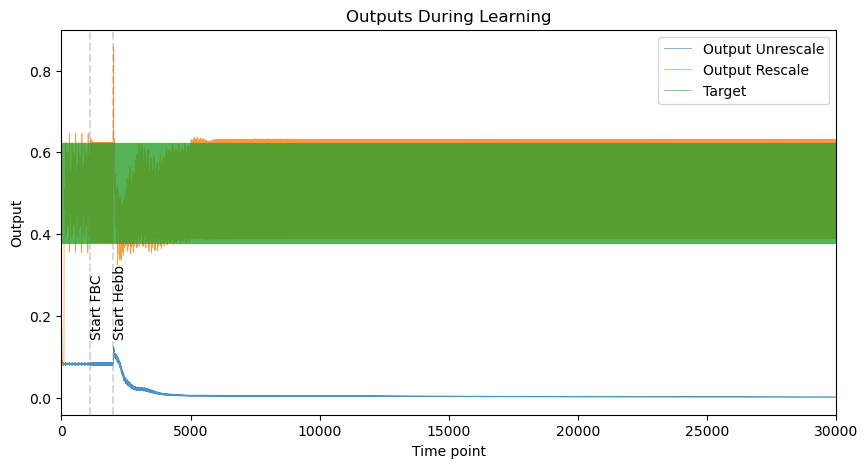

In [43]:
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(time_points, outputs_kris, label="Output Unrescale", alpha=0.8, lw=0.5)
plt.plot(time_points, outputs_kris_rescale, label="Output Rescale", alpha=0.8, lw=0.5)
plt.plot(time_points, targets, label="Target", alpha=0.8, lw=0.5)
plt.axvline(t_control, color="gray", linestyle="--", alpha=0.3)
plt.text(t_control, 0.15, "Start FBC", rotation=90)
plt.axvline(t_hebb, color="gray", linestyle="--", alpha=0.3)
plt.text(t_hebb, 0.15, "Start Hebb", rotation=90)
# plt.axvline(t_decay, color='gray', linestyle='--', alpha=0.3)
# plt.text(t_decay, 0.15, 'Start Decay', rotation=90)
plt.title("Outputs During Learning")
plt.xlabel("Time point")
plt.ylabel("Output")
plt.xlim(0, t_max)
plt.legend()
if SAVEFIG:
    plt.savefig(f"fig/{date}_{filename}_Kris_output.png")

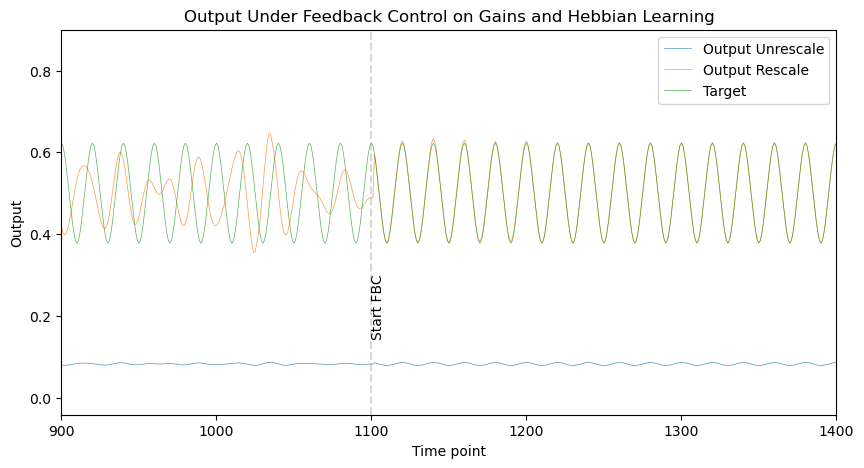

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(time_points, outputs_kris, label="Output Unrescale", alpha=0.8, lw=0.5)
plt.plot(time_points, outputs_kris_rescale, label="Output Rescale", alpha=0.8, lw=0.5)
plt.plot(time_points, targets, label="Target", alpha=0.8, lw=0.5)
plt.axvline(t_control, color="gray", linestyle="--", alpha=0.3)
plt.text(t_control, 0.15, "Start FBC", rotation=90)
# plt.axvline(t_hebb, color='gray', linestyle='--', alpha=0.3)
# plt.text(t_hebb, 0.15, 'Start Hebb', rotation=90)
# plt.axvline(t_decay, color='gray', linestyle='--', alpha=0.3)
# plt.text(t_decay, 0.15, 'Start Decay', rotation=90)
plt.title("Output Under Feedback Control on Gains and Hebbian Learning")
plt.xlabel("Time point")
plt.ylabel("Output")
plt.legend()
plt.xlim(900, 1400)
# if SAVEFIG:
#     plt.savefig(f"fig/{date}_{filename}_Kris_output_Zoom1.png")

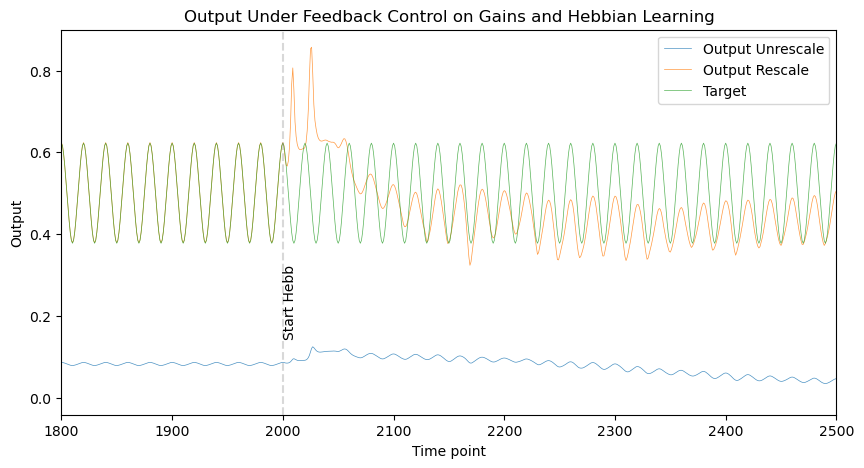

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(time_points, outputs_kris, label="Output Unrescale", alpha=0.8, lw=0.5)
plt.plot(time_points, outputs_kris_rescale, label="Output Rescale", alpha=0.8, lw=0.5)
plt.plot(time_points, targets, label="Target", alpha=0.8, lw=0.5)
# plt.axvline(t_control, color='gray', linestyle='--', alpha=0.3)
# plt.text(t_control, 0.15, 'Start FBC and Rescale', rotation=90)
plt.axvline(t_hebb, color="gray", linestyle="--", alpha=0.3)
plt.text(t_hebb, 0.15, "Start Hebb", rotation=90)
# plt.axvline(t_decay, color='gray', linestyle='--', alpha=0.3)
# plt.text(t_decay, 0.15, 'Start Decay', rotation=90)
plt.title("Output Under Feedback Control on Gains and Hebbian Learning")
plt.xlabel("Time point")
plt.ylabel("Output")
plt.legend()
plt.xlim(1800, 2500)
# if SAVEFIG:
#     plt.savefig(f"fig/{date}_{filename}_Kris_output_Zoom2.png")

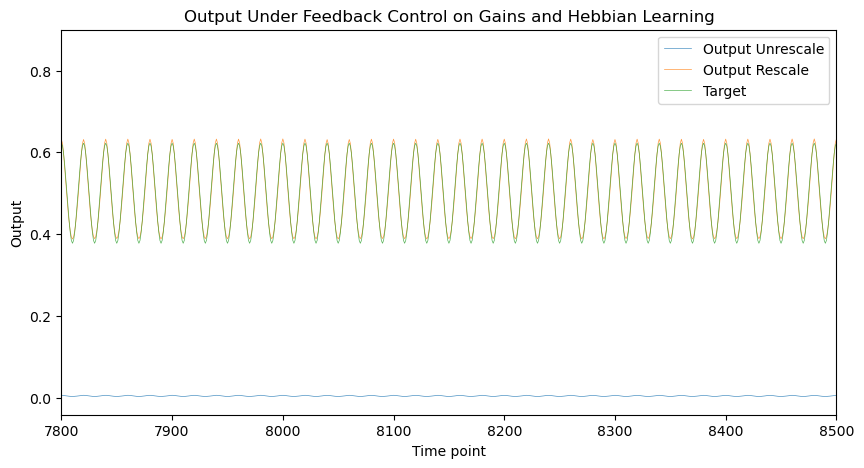

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(time_points, outputs_kris, label="Output Unrescale", alpha=0.8, lw=0.5)
plt.plot(time_points, outputs_kris_rescale, label="Output Rescale", alpha=0.8, lw=0.5)
plt.plot(time_points, targets, label="Target", alpha=0.8, lw=0.5)
plt.title("Output Under Feedback Control on Gains and Hebbian Learning")
plt.xlabel("Time point")
plt.ylabel("Output")
plt.legend()
plt.xlim(7800, 8500)
# if SAVEFIG:
#     plt.savefig(f"fig/{date}_{filename}_Kris_output_Zoom3.png")

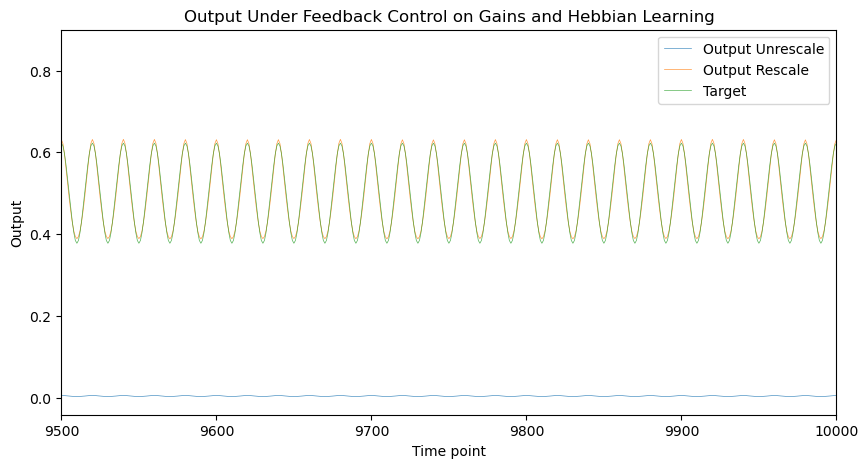

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(time_points, outputs_kris, label="Output Unrescale", alpha=0.8, lw=0.5)
plt.plot(time_points, outputs_kris_rescale, label="Output Rescale", alpha=0.8, lw=0.5)
plt.plot(time_points, targets, label="Target", alpha=0.8, lw=0.5)
plt.title("Output Under Feedback Control on Gains and Hebbian Learning")
plt.xlabel("Time point")
plt.ylabel("Output")
plt.legend()
plt.xlim(9500, 10000)
# if SAVEFIG:
#     plt.savefig(f"fig/{date}_{filename}_FBhebb_output_Zoom4.png")

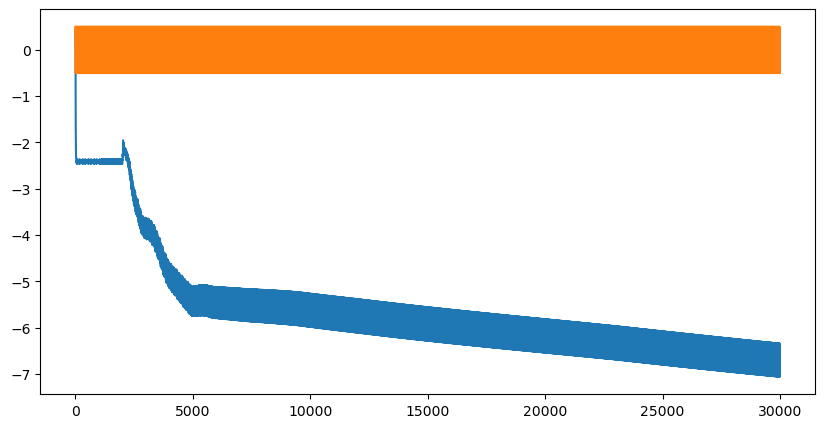

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(outputs_kris_beforesig)
plt.plot(y_tildes)

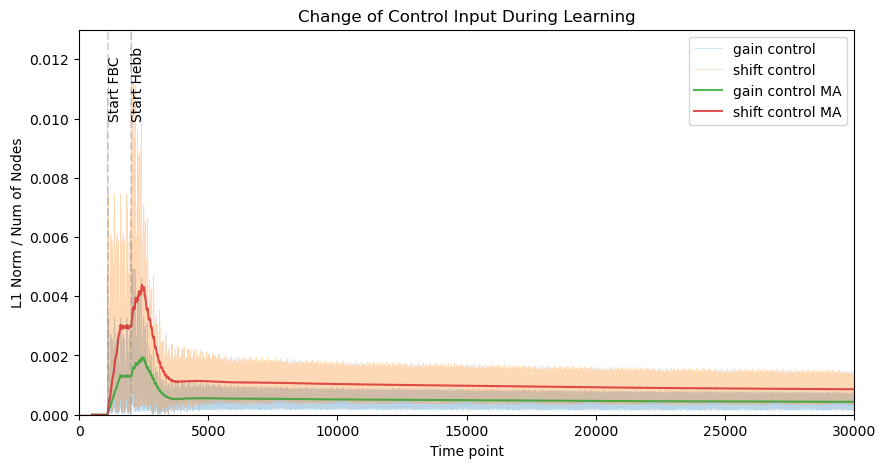

In [41]:
ugs_norm = [np.linalg.norm(u, 1) / u.shape[0] for u in ugs_kris]
uss_norm = [np.linalg.norm(u, 1) / u.shape[0] for u in uss_kris]
window = 500
ugs_norm_ma = np.convolve(ugs_norm, np.ones(window) / window, mode="valid")
uss_norm_ma = np.convolve(uss_norm, np.ones(window) / window, mode="valid")

fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(ugs_norm, label="gain control", alpha=0.3, lw=0.5)
plt.plot(uss_norm, label="shift control", alpha=0.3, lw=0.5)
plt.plot(np.arange(window - 1, len(ugs_norm)), ugs_norm_ma, label="gain control MA", alpha=0.8)
plt.plot(np.arange(window - 1, len(uss_norm)), uss_norm_ma, label="shift control MA", alpha=0.8)
plt.axvline(t_control, color="gray", linestyle="--", alpha=0.3)
plt.text(t_control, 0.01, "Start FBC", rotation=90)
plt.axvline(t_hebb, color="gray", linestyle="--", alpha=0.3)
plt.text(t_hebb, 0.01, "Start Hebb", rotation=90)
# plt.axvline(t_decay, color='gray', linestyle='--', alpha=0.3)
# plt.text(t_decay, 0.15, 'Start Decay', rotation=90)
plt.ylabel("L1 Norm / Num of Nodes")
plt.xlabel("Time point")
plt.title("Change of Control Input During Learning")
plt.legend()
plt.xlim(0, t_max)
plt.ylim(0, 0.013)
if SAVEFIG:
    plt.savefig(f"fig/{date}_{filename}_Kris_unorm.png")

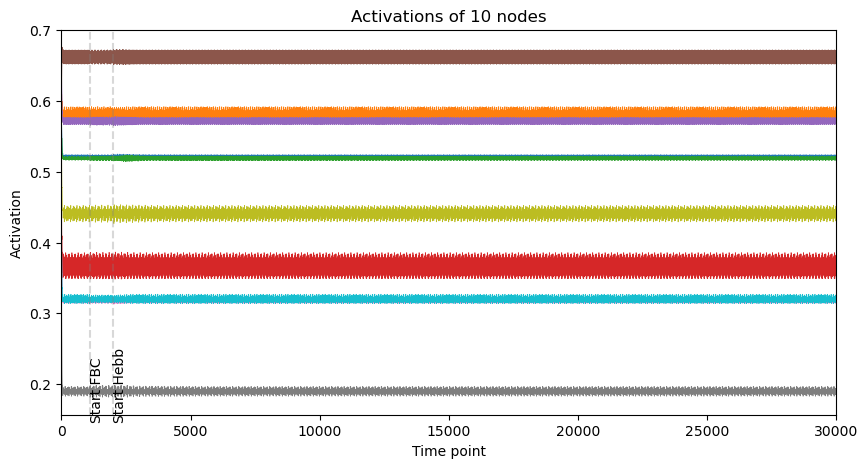

In [26]:
all_xs_kris = np.concatenate(xs_kris, axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
for i in range(10, 20):
    plt.plot(all_xs_kris[i, :], label=f"Node {i}", alpha=1, lw=0.5)
plt.axvline(t_control, color="gray", linestyle="--", alpha=0.3)
plt.text(t_control, 0.15, "Start FBC", rotation=90)
plt.axvline(t_hebb, color="gray", linestyle="--", alpha=0.3)
plt.text(t_hebb, 0.15, "Start Hebb", rotation=90)
# plt.axvline(t_decay, color='gray', linestyle='--', alpha=0.3)
# plt.text(t_decay, 0.15, 'Start Decay', rotation=90)
plt.xlim(0, t_max)
plt.xlabel("Time point")
plt.ylabel("Activation")
plt.title("Activations of 10 nodes")
# if SAVEFIG:
#     plt.savefig(f"fig/{date}_{filename}_Kris_activations.png")

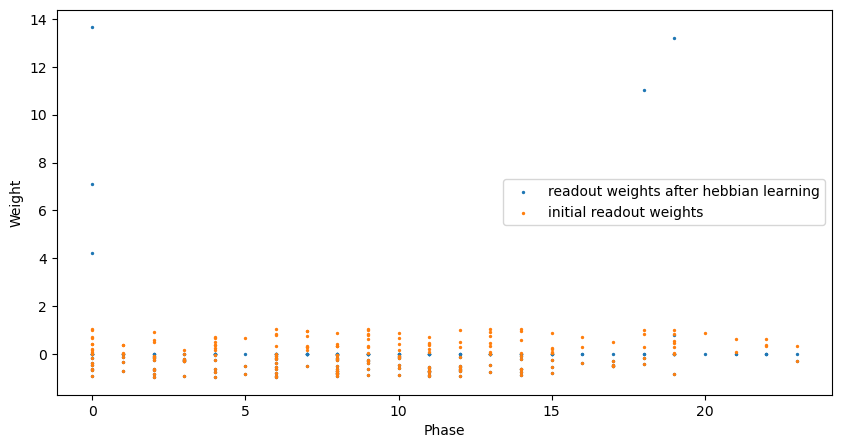

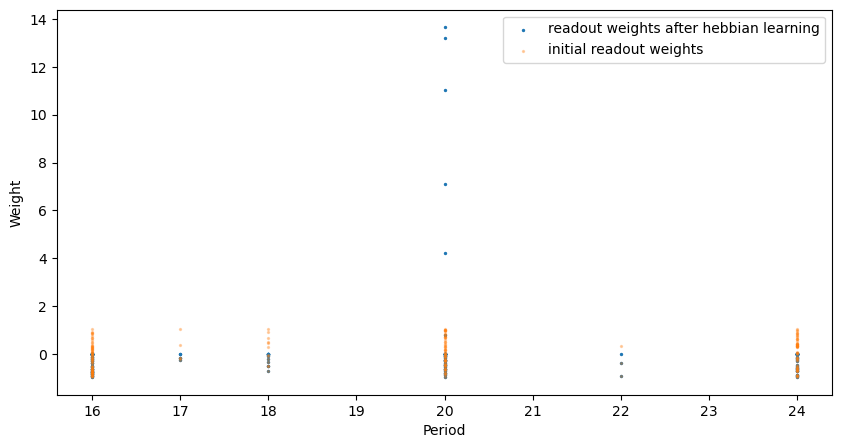

In [27]:
plt.subplots(figsize=(10, 5))
plt.scatter(phases, this_output_weight_matrix.flatten(), s=2, label="readout weights after hebbian learning")
plt.scatter(phases, init_output_weight_matrix.flatten(), s=2, label="initial readout weights")
plt.xlabel("Phase")
plt.ylabel("Weight")
plt.legend()
# if SAVEFIG:
#     plt.savefig(f"fig/{date}_{filename}_FBhebb_weights_phase_neg{neg_punishment}.png")

plt.subplots(figsize=(10, 5))
plt.scatter(periods, this_output_weight_matrix.flatten(), s=2, label="readout weights after hebbian learning")
plt.scatter(periods, init_output_weight_matrix.flatten(), s=2, label="initial readout weights", alpha=0.3)
plt.xlabel("Period")
plt.ylabel("Weight")
plt.legend()
# if SAVEFIG:
#     plt.savefig(f"fig/{date}_{filename}_FBhebb_weights_period_neg{neg_punishment}.png")

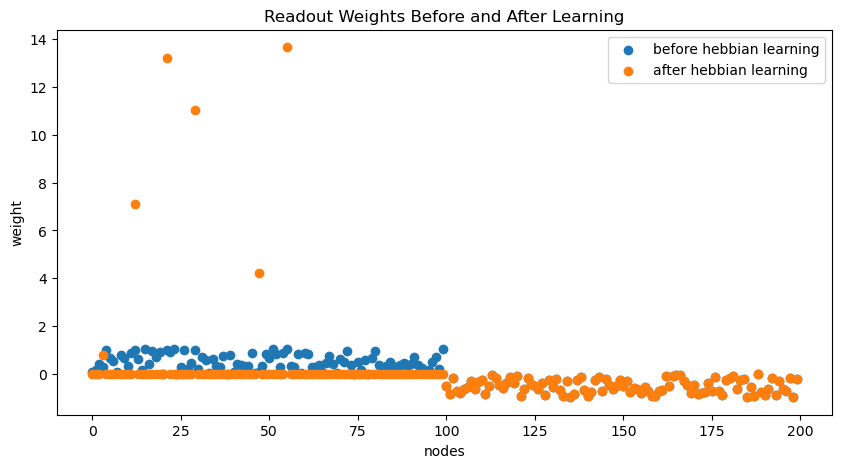

In [39]:
fig, ax = plt.subplots(figsize=(10, 5))
plt.scatter(np.arange(num_nodes), output_weight_matrix.reshape(-1, 1), label="before hebbian learning")
plt.scatter(np.arange(num_nodes), this_output_weight_matrix.reshape(-1, 1), label="after hebbian learning")
plt.xlabel("nodes")
plt.ylabel("weight")
plt.legend()
plt.title("Readout Weights Before and After Learning")
if SAVEFIG:
    plt.savefig(f"fig/{date}_{filename}_Kris_weightdist.png")

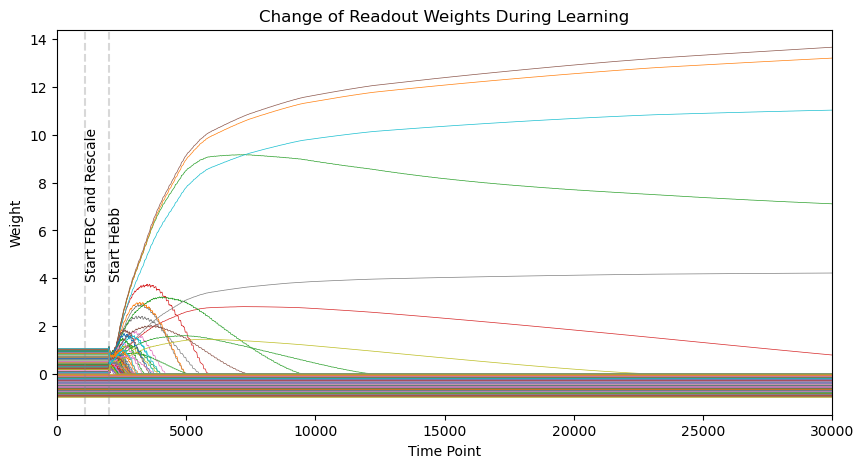

In [37]:
plt.subplots(figsize=(10, 5))
all_output_weights = np.concatenate(output_weights, axis=0).T
for i in range(num_nodes):
    plt.plot(all_output_weights[i, :], label=f"Node {i}", lw=0.5)
plt.axvline(t_control, color="gray", linestyle="--", alpha=0.3)
plt.text(t_control, 4, "Start FBC and Rescale", rotation=90)
plt.axvline(t_hebb, color="gray", linestyle="--", alpha=0.3)
plt.text(t_hebb, 4, "Start Hebb", rotation=90)
# plt.axvline(t_decay, color='gray', linestyle='--', alpha=0.3)
# plt.text(t_decay, -1, 'Start Decay', rotation=90)
plt.xlim(0, t_max)
plt.xlabel("Time Point")
plt.ylabel("Weight")
plt.title("Change of Readout Weights During Learning")
if SAVEFIG:
    plt.savefig(f"fig/{date}_{filename}_Kris_weights.png")

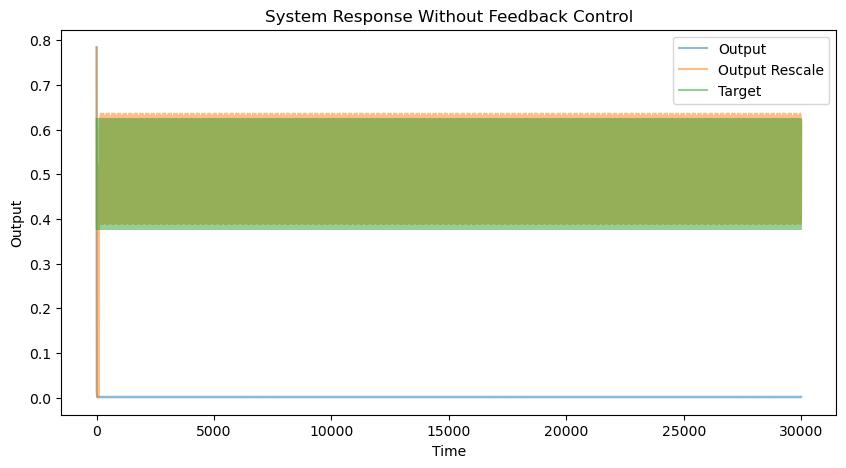

In [30]:
# Simulation Without Control
x = sigmoid_np(init_gain * (init_state.copy() - init_shift))
ug = init_state.copy() * 0
us = init_state.copy() * 0
# this_output_weight_matrix = output_weights[t_decay-1]
this_output_weight_matrix = output_weights[-1]
xs_ff_after, outputs_ff_after, outputs_ff_after_rescale = [x], [], []
lookback_out = 100

for i in time_points[:-1]:

    # output
    output_beforesig = this_output_weight_matrix @ x
    output = sigmoid_np(gainout * (output_beforesig - shiftout))

    # rescale output
    if i > lookback_out:
        ref_period_output = outputs_ff_after[-(lookback_output + 1) : -1]
        mean_coef, amp_coef = cal_rescale_coef(ref_period_output, desire_mean, desire_amp)
        output_rescale = output * amp_coef + mean_coef
    else:
        output_rescale = output

    # input
    this_input = inputs[:, i]
    r = feedback_weight_matrix * this_input.reshape(-1, 1)

    # update x
    x1 = jnn_ff.f(x, ug, us, r)
    x = x1.copy()

    # save
    xs_ff_after.append(x)
    outputs_ff_after.append(output.item())
    outputs_ff_after_rescale.append(output_rescale.item())

# final readout for x_T
output_beforesig = this_output_weight_matrix @ x
output = sigmoid_np(gainout * (output_beforesig - shiftout))
ref_period_output = outputs_ff_after[-(lookback_output + 1) : -1]
mean_coef, amp_coef = cal_rescale_coef(ref_period_output, desire_mean, desire_amp)
output_rescale = output * amp_coef + mean_coef
outputs_ff_after.append(output.item())
outputs_ff_after_rescale.append(output_rescale.item())

# Plot the output
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(time_points, outputs_ff_after, alpha=0.5, label="Output")
plt.plot(time_points, outputs_ff_after_rescale, alpha=0.5, label="Output Rescale")
plt.plot(time_points, targets, alpha=0.5, label="Target")
plt.xlabel("Time")
plt.ylabel("Output")
plt.title("System Response Without Feedback Control")
plt.legend()
plt.show()

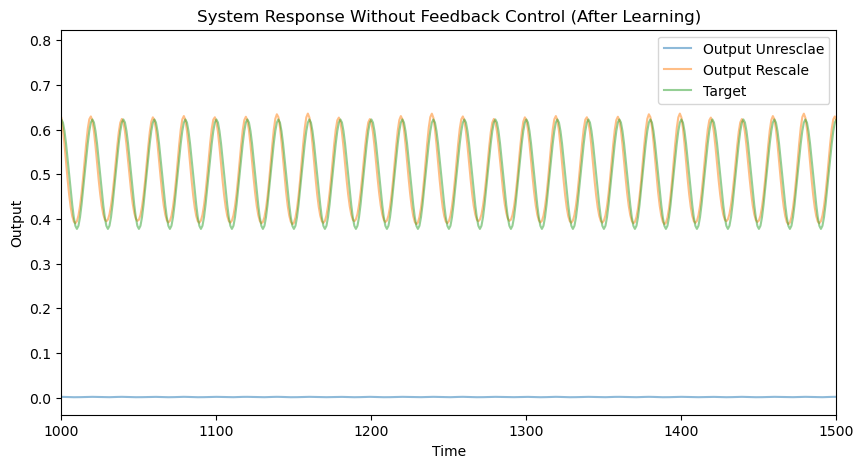

In [34]:
# Plot the output
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(time_points, outputs_ff_after, alpha=0.5, label="Output Unresclae")
plt.plot(time_points, outputs_ff_after_rescale, alpha=0.5, label="Output Rescale")
plt.plot(time_points, targets, alpha=0.5, label="Target")
plt.xlabel("Time")
plt.ylabel("Output")
plt.xlim(1000, 1500)
plt.title("System Response Without Feedback Control (After Learning)")
plt.legend()
if SAVEFIG:
    plt.savefig(f"fig/{date}_{filename}_Kris_outputs_after.png")